# Day 4: Fund Performance Analytics

This notebook computes key performance metrics for all 40 schemes, builds a scorecard, and compares performance against benchmarks.

In [1]:

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('../reports/data', exist_ok=True)

# Load datasets
raw_dir = '../data/processed/'
df_nav = pd.read_csv(raw_dir + '02_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

df_fund = pd.read_csv(raw_dir + '01_fund_master.csv')

df_bench = pd.read_csv(raw_dir + '10_benchmark_indices.csv')
df_bench['date'] = pd.to_datetime(df_bench['date'])
df_bench = df_bench.sort_values(['index_name', 'date'])


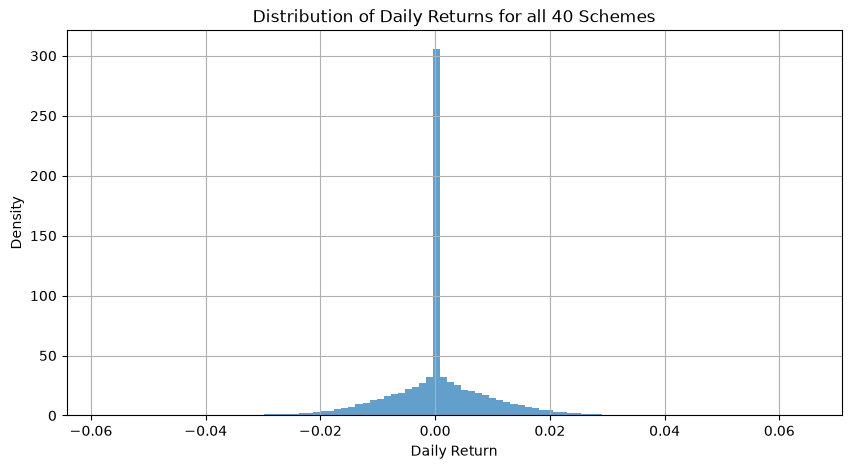

Daily returns computed and distribution looks roughly normal with fat tails as expected.


In [2]:

# 1. Compute daily returns
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

plt.figure(figsize=(10, 5))
df_nav['daily_return'].hist(bins=100, density=True, alpha=0.7)
plt.title('Distribution of Daily Returns for all 40 Schemes')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.show()

print("Daily returns computed and distribution looks roughly normal with fat tails as expected.")


In [3]:

# 2. Compute CAGR for 1yr, 3yr, 5yr
def compute_cagr(df_group, years):
    df_group = df_group.sort_values('date')
    if len(df_group) == 0:
        return np.nan
    end_date = df_group['date'].iloc[-1]
    start_date = end_date - pd.DateOffset(years=years)
    
    df_period = df_group[df_group['date'] >= start_date]
    n_trading_days = len(df_period)
    
    # Require at least half the expected trading days
    if n_trading_days < (252 * years * 0.5):
        return np.nan
        
    nav_start = df_period['nav'].iloc[0]
    nav_end = df_period['nav'].iloc[-1]
    
    # Annualize using trading days (252 / n_trading_days)
    return (nav_end / nav_start) ** (252 / n_trading_days) - 1

cagr_1y = df_nav.groupby('amfi_code').apply(lambda x: compute_cagr(x, 1)).rename('cagr_1yr')
cagr_3y = df_nav.groupby('amfi_code').apply(lambda x: compute_cagr(x, 3)).rename('cagr_3yr')
cagr_5y = df_nav.groupby('amfi_code').apply(lambda x: compute_cagr(x, 5)).rename('cagr_5yr')

df_cagr = pd.concat([cagr_1y, cagr_3y, cagr_5y], axis=1).reset_index()
display(df_cagr.head())


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.015368,0.008891,0.018109
1,100025,0.025365,0.026828,0.030531
2,100033,0.341586,0.213655,0.199081
3,101206,0.309411,0.191621,0.156906
4,101207,-0.172073,-0.028804,0.054086


In [4]:

# 3 & 4. Sharpe and Sortino Ratios
rf = 0.065 # 6.5% RBI repo rate proxy
rf_daily = rf / 252

def compute_ratios(x):
    rets = x.dropna()
    if len(rets) < 100:
        return pd.Series({'sharpe': np.nan, 'sortino': np.nan})
    
    excess_ret = rets - rf_daily
    mean_excess = excess_ret.mean()
    std_ret = rets.std()
    
    sharpe = (mean_excess / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan
    
    downside = rets[rets < 0]
    std_down = downside.std()
    sortino = (mean_excess / std_down) * np.sqrt(252) if std_down > 0 else np.nan
    
    return pd.Series({'sharpe': sharpe, 'sortino': sortino})

df_ratios = df_nav.groupby('amfi_code')['daily_return'].apply(compute_ratios).unstack().reset_index()
df_ratios['sharpe_rank'] = df_ratios['sharpe'].rank(ascending=False)
display(df_ratios.head())


,amfi_code,sharpe,sortino,sharpe_rank
0,100016,-0.321019,-0.472822,34.0
1,100025,-1.039941,-1.461220,37.0
2,100033,0.808268,1.144216,7.0
3,101206,0.717409,1.063909,10.0
4,101207,0.052618,0.075668,27.0


In [5]:

# 5. Alpha and Beta against Nifty 100
nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'][['date', 'close_value']].rename(columns={'close_value': 'nifty_close'})
nifty100['nifty_ret'] = nifty100['nifty_close'].pct_change()

df_merged = pd.merge(df_nav[['amfi_code', 'date', 'daily_return']].dropna(), nifty100[['date', 'nifty_ret']].dropna(), on='date', how='inner')

def calc_alpha_beta(group):
    res = stats.linregress(group['nifty_ret'], group['daily_return'])
    alpha_ann = res.intercept * 252
    beta = res.slope
    return pd.Series({'alpha': alpha_ann, 'beta': beta})

df_ab = df_merged.groupby('amfi_code').apply(calc_alpha_beta).reset_index()
df_ab.to_csv('../reports/data/alpha_beta.csv', index=False)
display(df_ab.head())


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [6]:

# 6. Maximum Drawdown
def calc_max_dd(group):
    group = group.sort_values('date')
    cummax = group['nav'].cummax()
    drawdown = (group['nav'] / cummax) - 1
    min_dd = drawdown.min()
    # Find worst drawdown date range
    worst_idx = drawdown.idxmin()
    worst_date = group.loc[worst_idx, 'date']
    # Start of drawdown is the cummax date before worst date
    start_dd_val = cummax.loc[worst_idx]
    start_date = group[(group['nav'] == start_dd_val) & (group['date'] <= worst_date)]['date'].min()
    return pd.Series({'max_dd': min_dd, 'dd_start': start_date, 'dd_worst': worst_date})

df_dd = df_nav.groupby('amfi_code').apply(calc_max_dd).reset_index()
display(df_dd.head())


,amfi_code,max_dd,dd_start,dd_worst
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [7]:

# 7. Fund Scorecard
# Merge all metrics
df_score = df_cagr.merge(df_ratios, on='amfi_code')
df_score = df_score.merge(df_ab, on='amfi_code')
df_score = df_score.merge(df_dd[['amfi_code', 'max_dd']], on='amfi_code')
df_score = df_score.merge(df_fund[['amfi_code', 'expense_ratio_pct', 'scheme_name']], on='amfi_code')

# Percentile ranks (0 to 100)
r_3yr = df_score['cagr_3yr'].rank(pct=True) * 100
r_sharpe = df_score['sharpe'].rank(pct=True) * 100
r_alpha = df_score['alpha'].rank(pct=True) * 100
r_exp = df_score['expense_ratio_pct'].rank(ascending=False, pct=True) * 100 # inverse
r_dd = df_score['max_dd'].rank(pct=True) * 100 # max_dd is negative, less negative is higher rank

# Composite score: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank + 10% × max DD rank
df_score['composite_score'] = (0.30 * r_3yr) + (0.25 * r_sharpe) + (0.20 * r_alpha) + (0.15 * r_exp) + (0.10 * r_dd)

df_score = df_score.sort_values('composite_score', ascending=False)
df_score.to_csv('../reports/data/fund_scorecard.csv', index=False)
display(df_score[['scheme_name', 'composite_score', 'cagr_3yr', 'sharpe', 'alpha', 'expense_ratio_pct', 'max_dd']].head(10))


,scheme_name,composite_score,cagr_3yr,sharpe,alpha,expense_ratio_pct,max_dd
34,Mirae Asset Large Cap Fund - Regular - Growth,86.2500,0.223479,1.068224,0.269838,1.46,-0.112657
25,ICICI Pru Midcap Fund - Regular - Growth,82.8750,0.209453,0.883256,0.292636,1.36,-0.181885
30,Kotak Flexicap Fund - Regular - Growth,82.0000,0.195535,0.965561,0.273305,1.45,-0.129740
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500,0.213655,0.808268,0.271954,1.38,-0.162172
24,ICICI Pru Bluechip Fund - Direct - Growth,79.3750,0.213939,0.714682,0.211948,0.80,-0.125883
16,Axis Midcap Fund - Regular - Growth,78.2500,0.230460,0.730547,0.260767,1.38,-0.209609
19,SBI Bluechip Fund - Regular Plan - Growth,74.1875,0.201084,0.860977,0.232010,1.54,-0.150124
36,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875,0.192966,0.919047,0.282704,1.60,-0.163967
21,SBI Small Cap Fund - Regular Plan - Growth,68.0000,0.176949,0.711690,0.303370,1.43,-0.287060
3,ABSL Frontline Equity Fund - Regular - Growth,67.5625,0.191621,0.717409,0.213998,1.60,-0.112916


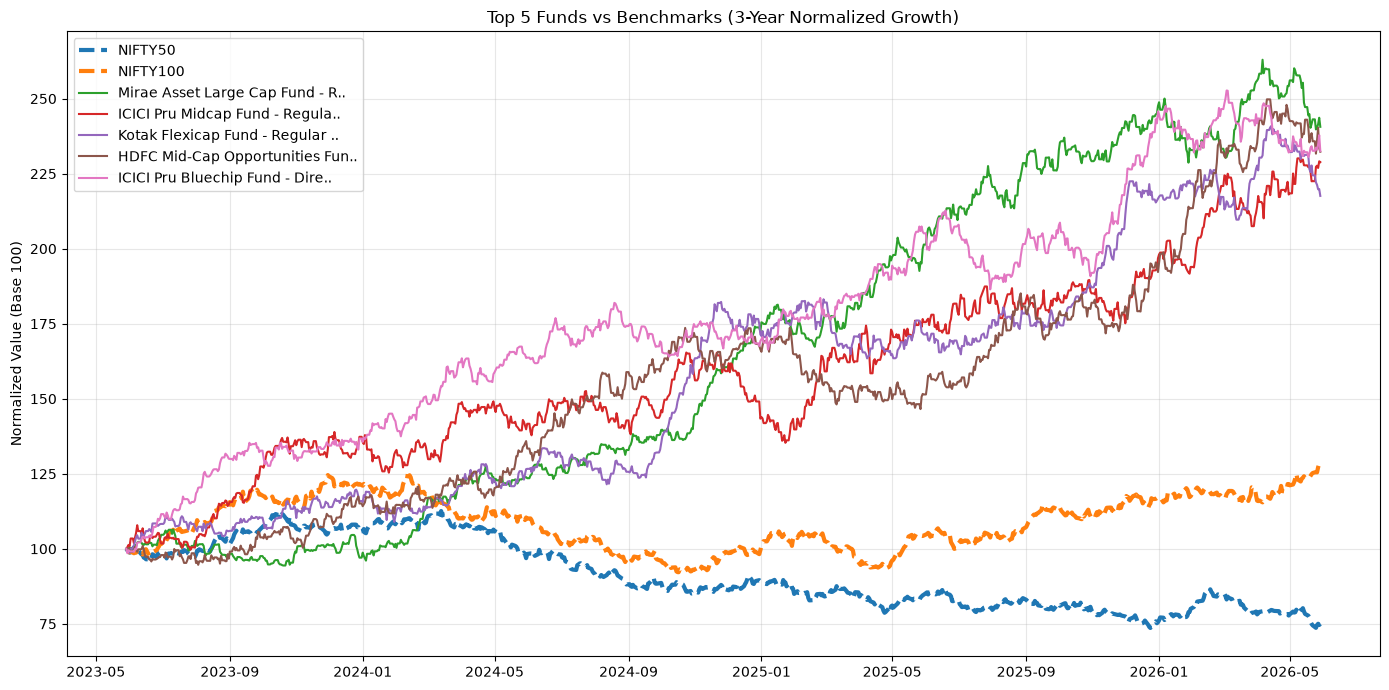

,Fund,Tracking Error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.187974
1,ICICI Pru Midcap Fund - Regular - Growth,0.232661
2,Kotak Flexicap Fund - Regular - Growth,0.206540
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224976
4,ICICI Pru Bluechip Fund - Direct - Growth,0.187299


In [8]:

# 8. Benchmark comparison chart
top_5_amfi = df_score.head(5)['amfi_code'].tolist()

# Get 3 years data
end_date = df_nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

df_nav_3y = df_nav[(df_nav['date'] >= start_date) & (df_nav['amfi_code'].isin(top_5_amfi))]
df_bench_3y = df_bench[(df_bench['date'] >= start_date) & (df_bench['index_name'].isin(['NIFTY50', 'NIFTY100']))]

plt.figure(figsize=(14, 7))

# Plot Nifty 50 and 100
for idx in ['NIFTY50', 'NIFTY100']:
    d = df_bench_3y[df_bench_3y['index_name'] == idx].sort_values('date')
    d['norm_val'] = d['close_value'] / d['close_value'].iloc[0] * 100
    plt.plot(d['date'], d['norm_val'], label=idx, linewidth=3, linestyle='--')

# Plot top 5 funds
for code in top_5_amfi:
    d = df_nav_3y[df_nav_3y['amfi_code'] == code].sort_values('date')
    d['norm_val'] = d['nav'] / d['nav'].iloc[0] * 100
    name = df_fund[df_fund['amfi_code']==code]['scheme_name'].values[0]
    # shorten name
    name = name[:30] + '..' if len(name) > 30 else name
    plt.plot(d['date'], d['norm_val'], label=name)

plt.title('Top 5 Funds vs Benchmarks (3-Year Normalized Growth)')
plt.ylabel('Normalized Value (Base 100)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/charts/benchmark_comparison.png')
plt.show()

# Compute tracking error against NIFTY 100 for top 5
te_data = []
nifty100_ret = df_bench_3y[df_bench_3y['index_name'] == 'NIFTY100'].set_index('date')['close_value'].pct_change()
for code in top_5_amfi:
    fund_ret = df_nav_3y[df_nav_3y['amfi_code'] == code].set_index('date')['nav'].pct_change()
    diff = fund_ret - nifty100_ret
    te = diff.std() * np.sqrt(252)
    name = df_fund[df_fund['amfi_code']==code]['scheme_name'].values[0]
    te_data.append({'Fund': name, 'Tracking Error': te})

display(pd.DataFrame(te_data))
